<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

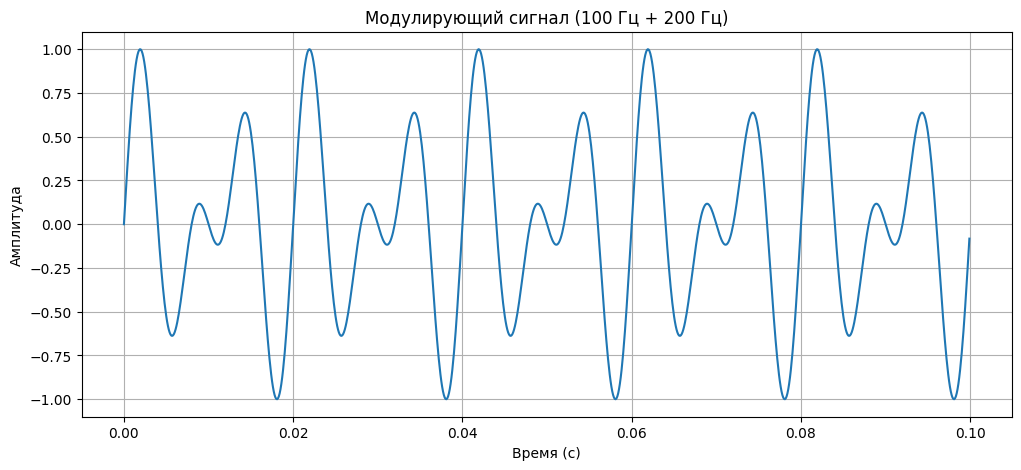

In [60]:
fm1 = 100
fm2 = 150
m_t =  Ac * np.sin(2 * np.pi * fm1 * t ) + Ac * np.sin(2 * np.pi * fm2 * t ) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]
m_t = m_t / np.max(np.abs(m_t))
plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [61]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [62]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

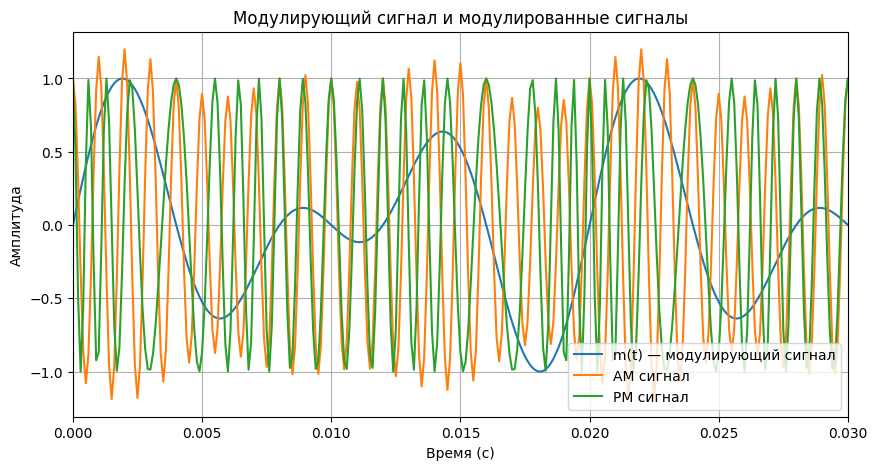

In [63]:
plt.figure(figsize=(10, 5))

plt.plot(t, m_t,  label='m(t) — модулирующий сигнал')
plt.plot(t, s_am, label='AM сигнал')
plt.plot(t, s_pm,  label='PM сигнал')

plt.title('Модулирующий сигнал и модулированные сигналы')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.legend(loc='lower right')
plt.grid(True)

plt.xlim(0, 0.03)

plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [64]:
def plot_spectrum(s, fs, title):
  N = len(s)
  X = np.fft.fft(s)
  freq = np.fft.fftfreq(N, d = 1/ fs)

  half = N // 2
  freq_pos = freq[:half]
  amplitude = np.abs(X[:half])/half


  fig, ax = plt.subplots(linewidth=1)
  ax.plot(freq_pos, amplitude, linewidth=1)
  ax.set_title(title)
  ax.set_xlabel('Частота (Гц)')
  ax.set_ylabel('Амплитуда')
  ax.grid(True)
  ax.set_xlim(0, 3000)
  fig.tight_layout()
  plt.show()

### 2.2. Спектр АМ

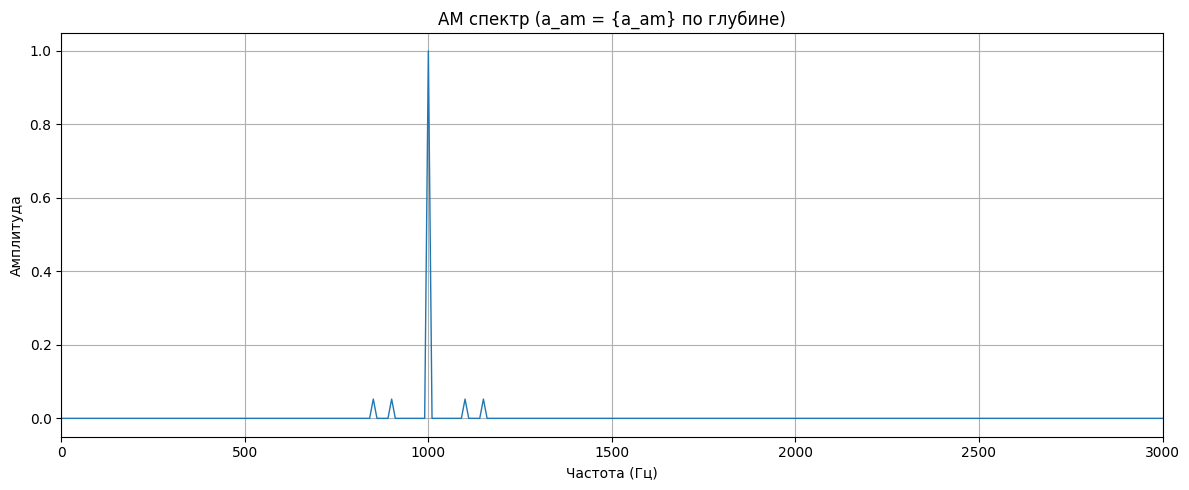

In [65]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

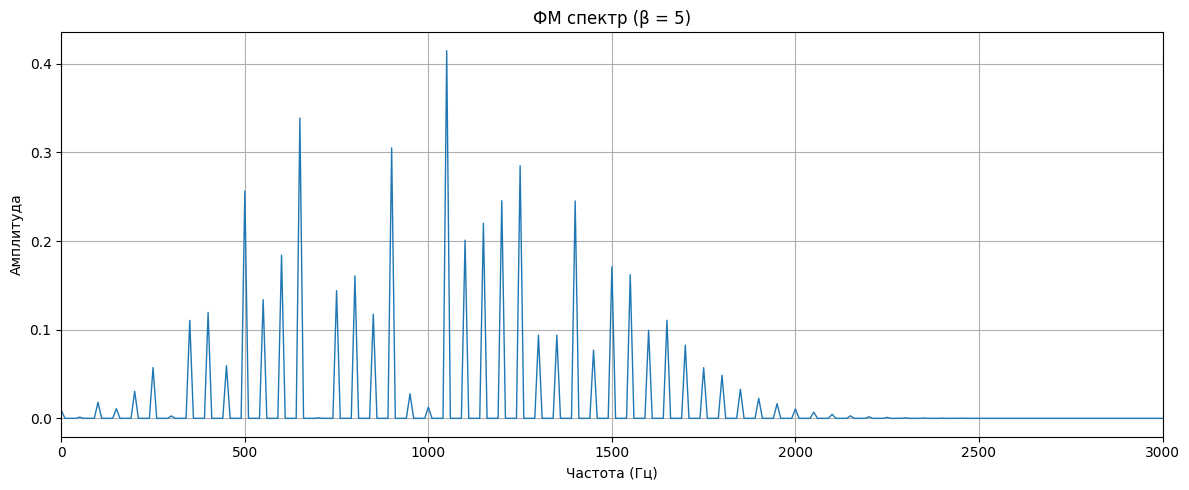

In [66]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

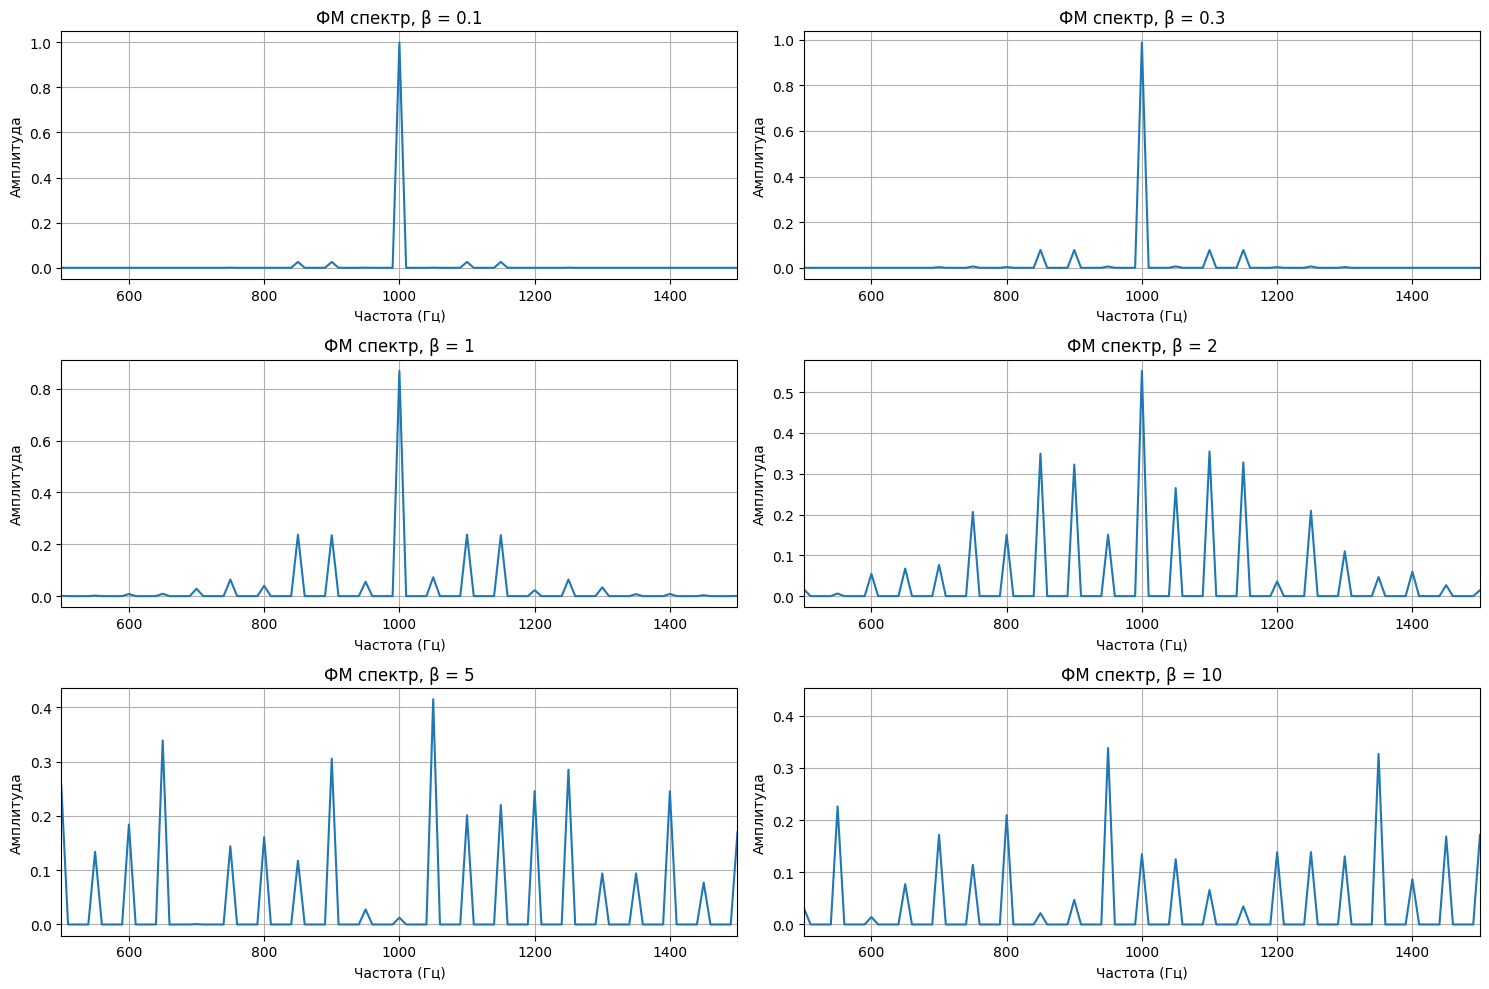

In [67]:
betas = [0.1, 0.3, 1, 2, 5, 10]
plt.figure(figsize=(15, 10))

for i, b in enumerate(betas):
    s = Ac * np.cos(2 * np.pi * fc * t + b * m_t)
    N = len(s)
    X = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, 1/fs)
    half_N = N // 2

    plt.subplot(3, 2, i + 1)
    plt.plot(freqs[:half_N], np.abs(X[:half_N]) * 2 / N)
    plt.title(f'ФМ спектр, β = {b}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(500, 1500)

plt.tight_layout()
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [68]:
def pm_spectrum(beta=5):
    s = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
    plot_spectrum(s, fs, f'ФМ спектр (β = {beta})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

Модулирующий сигнал представляет собой сумму двух синусоид с частотами 100 Гц и 200 Гц.Амплитудная модуляция является линейным процессом: спектр АМ-сигнала образуется свёрткой спектра несущего колебания (одна линия на частоте fc ) со спектром модулирующего сигнала (две линии на частотах 100 Гц и 200 Гц).

При малых значениях β  содержит три ярко выраженные компоненты – несущую на частоте fc и две боковые полосы на частотах fc+fm и fc-fm. Однако в отличие от АМ, здесь боковые полосы имеют противоположные знаки, что приводит к тому, что огибающая сигнала остаётся постоянной, а меняется только фаза.

С ростом индекса β:
  
  Амплитуда несущей уменьшается.

  Появляются и растут амплитуды боковых полос более высоких порядков.

  Общая ширина спектра увеличивается.


## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

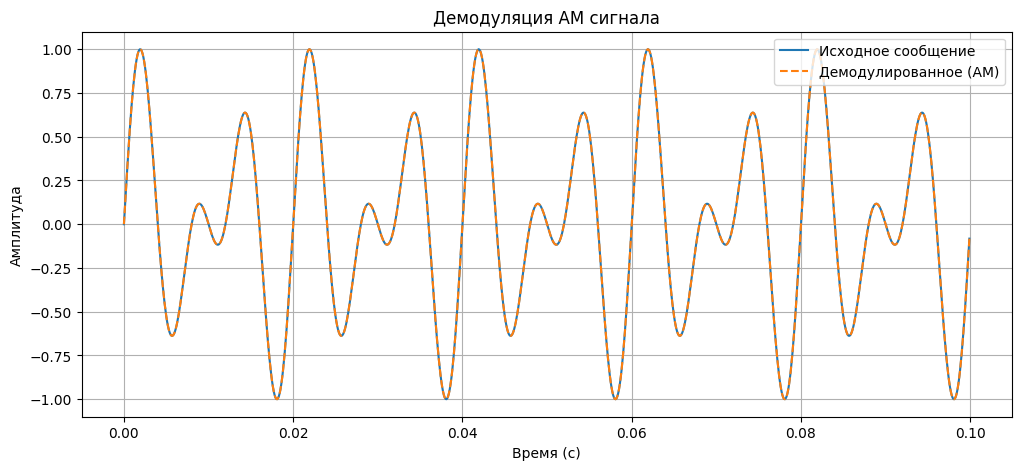

In [69]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [70]:
error = m_t - demod_am
rmse = np.std(error)
print(f"Среднеквадратичная ошибка (RMSE): {rmse:.6f}")


Среднеквадратичная ошибка (RMSE): 0.000000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

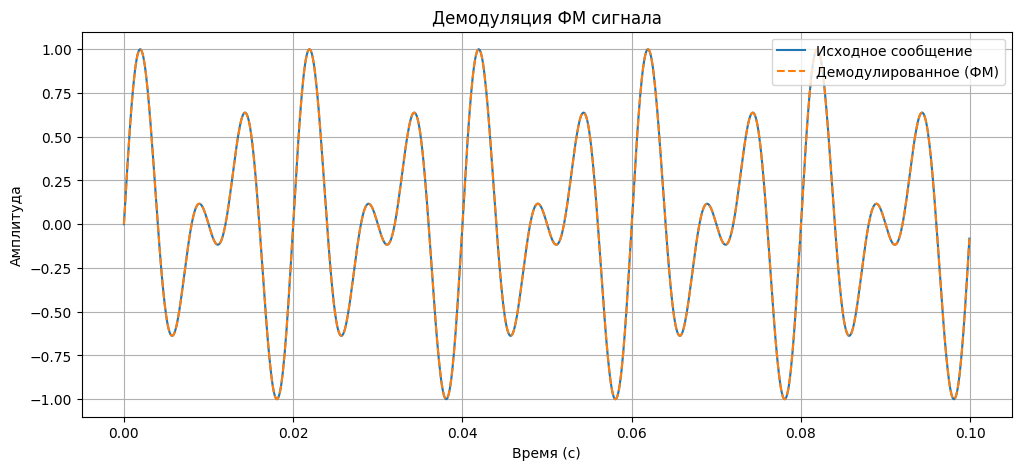

In [71]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

При вычислении фазы через `np.angle` результат лежит в пределах $[-\pi, \pi]$. Если истинная фаза пересекает эти границы, возникают скачки на $2\pi$. `np.unwrap` добавляет или вычитает $2\pi$ в местах скачков, восстанавливая непрерывную фазу.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [72]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-03-29 20:54:56--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-03-29 20:54:56--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.09s   

2026-03-29 20:54:56 (5.93 MB/s) - ‘audio.wav’ saved [563756/563756]



In [73]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

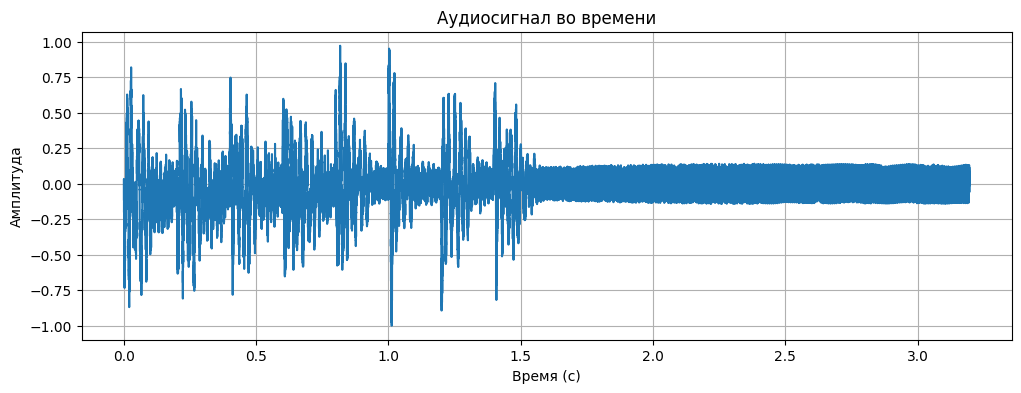

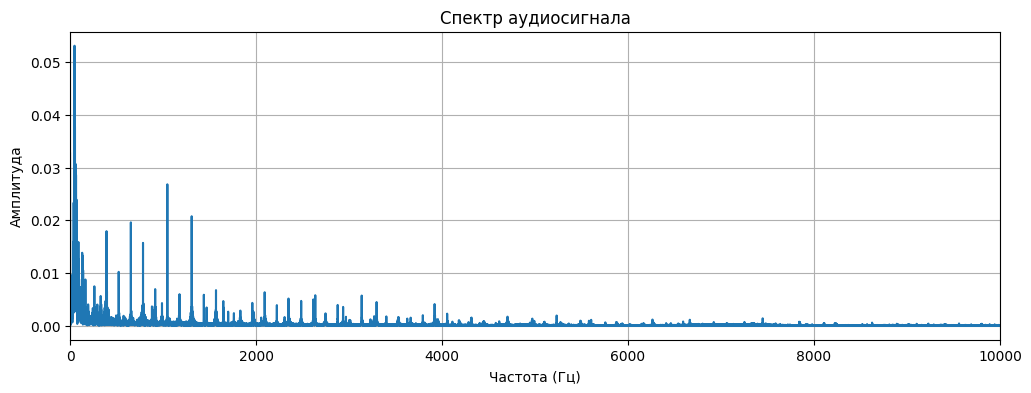

In [74]:
plt.figure(figsize=(12, 4))
plt.plot(t_audio, melody)
plt.title('Аудиосигнал во времени')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

N_audio = len(melody)
X_audio = np.fft.fft(melody)
freqs_audio = np.fft.fftfreq(N_audio, 1/fs_audio)
half_N = N_audio // 2

plt.figure(figsize=(12, 4))
plt.plot(freqs_audio[:half_N], np.abs(X_audio[:half_N]) * 2 / N_audio)
plt.title('Спектр аудиосигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 10000)
plt.grid(True)
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

На амплитудном спектре  видно, что основная энергия и заметные пики сосредоточены в диапазоне примерно до 2 кГц.

При частоте дискретизации 44,1 кГц частота Найквиста составляет fs/2=22,05 кГц. По правилу Карсона BW≈2(Δf+fm)=2fm(1+β), Спектр FM-сигнала должен уместиться в [0, 22.05] кГц, чтобы избежать наложения и потери боковых полос, несущих информацию о пиках базового сигнала. fc+BW/2 <22,05 кГц : Если взять
fm≈2fm≈2 кГц и запас по ширине спектра, получаем BW≈8 кГц. Тогда fc безопасно выбрать в диапазоне от 5 до 15 кГц.

Индекс модуляции β напрямую определяет ширину спектра фазомодулированного сигнала.

При малых β спектр сосредоточен вблизи несущей и занимает полосу порядка 2fm, поэтому можно выбрать несущую ближе к верхней границе аудиодиапазона без риска выхода за Найквиста.

При больших β спектр сильно расширяется, и несущую необходимо выбирать ниже, чтобы боковые полосы не вышли за пределы
fs/2.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [75]:
fc_high = 10000 # несущая 10 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [76]:
# АМ
a_am = 0.1
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 5
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [77]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

Среднеквадратичная ошибка (MSE): 0.000773


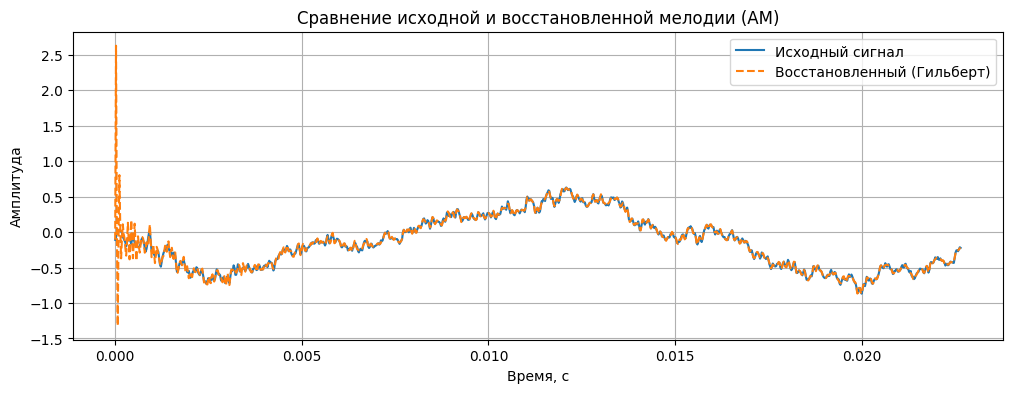

In [78]:
analytic = hilbert(s_am_audio)
envelope = np.abs(analytic)
melody_restored = (envelope / Ac - 1) / a_am

mse = np.mean((melody - melody_restored)**2)
print(f'Среднеквадратичная ошибка (MSE): {mse:.6f}')

plt.figure(figsize=(12, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored[:1000], '--', label='Восстановленный (Гильберт)')
plt.legend()
plt.title('Сравнение исходной и восстановленной мелодии (АМ)')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Демодулируйте зашумлёный АМ-сигнал.

MSE для зашумлённого сигнала: 0.720805


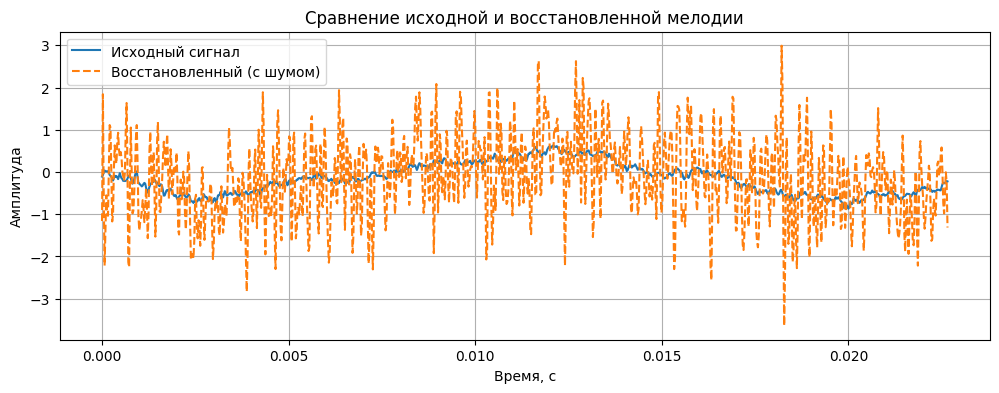

In [79]:
# Демодуляция зашумлённого АМ-сигнала
analytic_noisy = hilbert(s_am_noisy)
envelope_noisy = np.abs(analytic_noisy)
melody_restored_noisy = (envelope_noisy / Ac - 1) / a_am

mse_noisy = np.mean((melody - melody_restored_noisy)**2)
print(f'MSE для зашумлённого сигнала: {mse_noisy:.6f}')

plt.figure(figsize=(12, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored_noisy[:1000], '--', label='Восстановленный (с шумом)')
plt.legend()
plt.title('Сравнение исходной и восстановленной мелодии')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

Да, качество звука заметно ухудшилось.

Фиксируем  $a_{AM}=0{,}2$. При значении 0.01 разница минимальная, при 0.03 уже появляются артефакты, при 0.1 и больше искажения становятся видимы и слышимы более сильно.

Фиксируем амплитуду шума равную 0.01.При изменении
$a_{AM}=$  от 0,1 до 1,0:

$a_{AM}$≥0,5 — влияние шума становится практически незаметным​.

$a_{AM}$≈0,2 — искажения слышны слабо.

$a_{AM}$≤0,1 — сигнал сильно зашумлён.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

MSE: 0.000035


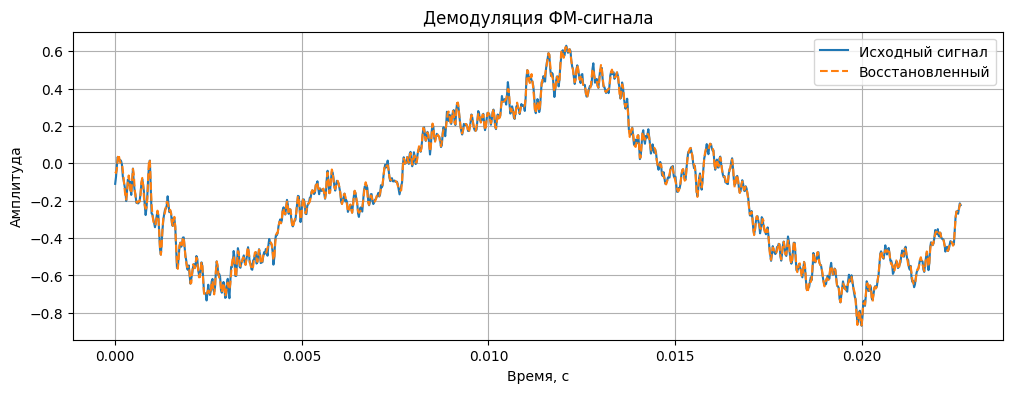

In [80]:
analytic = hilbert(s_pm_audio)                     # аналитический сигнал
instant_phase = np.unwrap(np.angle(analytic))      # мгновенная фаза
carrier_phase = 2 * np.pi * fc_high * t_audio      # фаза несущей
melody_restored = (instant_phase - carrier_phase) / beta_pm_audio   # восстановление

# Оценка качества
mse = np.mean((melody - melody_restored)**2)
print(f'MSE: {mse:.6f}')

# Визуализация фрагмента
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored[:1000], '--', label='Восстановленный')
plt.legend()
plt.title('Демодуляция ФМ-сигнала')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

Демодулируйте зашумлёный ФМ-сигнал.

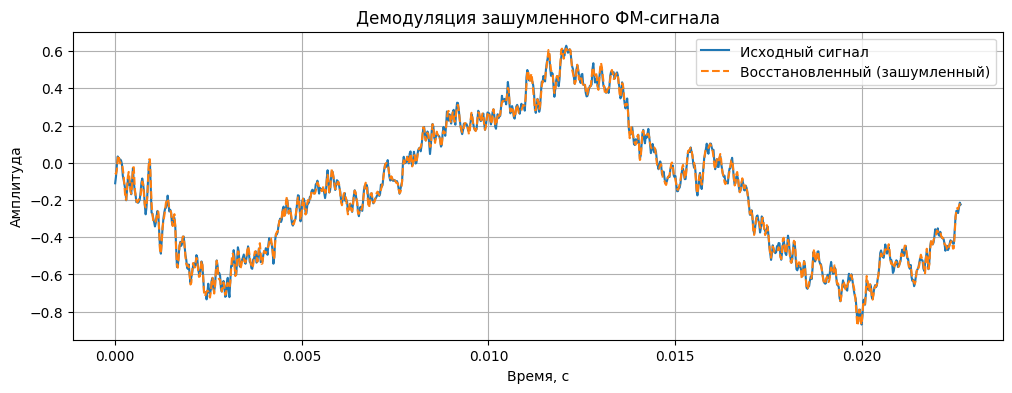

In [81]:
# Демодуляция зашумлённого ФМ-сигнала
analytic_noisy = hilbert(s_pm_noisy)                     # аналитический сигнал
instant_phase_noisy = np.unwrap(np.angle(analytic_noisy)) # мгновенная фаза
carrier_phase = 2 * np.pi * fc_high * t_audio            # фаза несущей
melody_restored_noisy = (instant_phase_noisy - carrier_phase) / beta_pm_audio


plt.figure(figsize=(12, 4))
plt.plot(t_audio[:1000], melody[:1000], label='Исходный сигнал')
plt.plot(t_audio[:1000], melody_restored_noisy[:1000], '--', label='Восстановленный (зашумленный)')
plt.legend()
plt.title('Демодуляция зашумленного ФМ-сигнала')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

Качество при заданных параметрах изменилось слабо.

Фиксируем $\beta=2$. Разница появляется при амплитуде = 0.2 и чем выше тем хуже становится.

Фиксируем ампилуту 0.1. При $\beta=1$ звук сильно искажён, при $\beta=5$ звук сильно похож на оригинал. Субъективная величина искажений уменьшается с ростом $\beta$.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

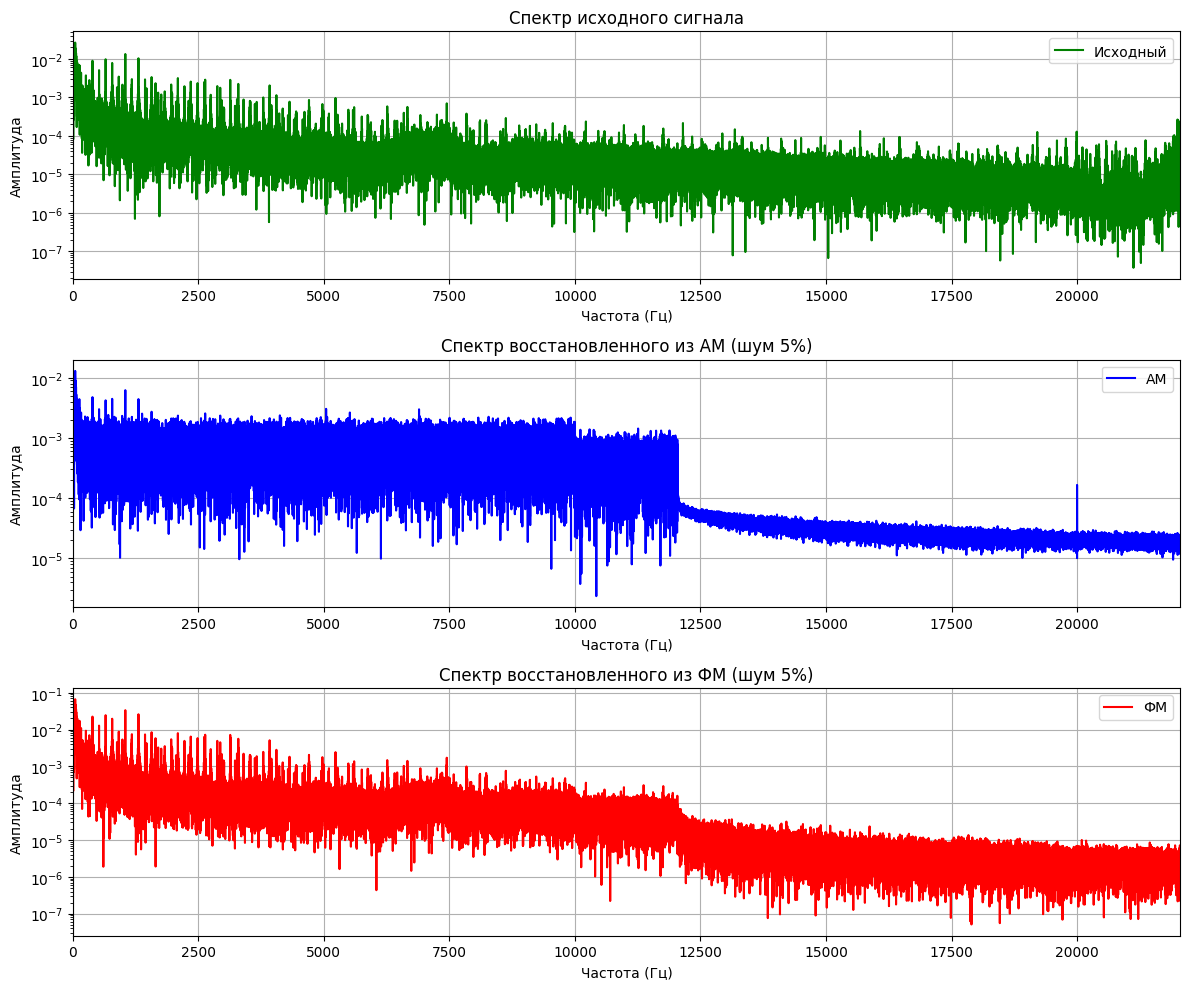

In [82]:
a_am = 0.2
beta_pm_audio = 2
noise_amp_scale = 0.05
np.random.seed(42)

noise_amp = noise_amp_scale * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

analytic_am = hilbert(s_am_noisy)
envelope_am = np.abs(analytic_am)
melody_restored_am = (envelope_am / Ac - 1) / a_am

analytic_pm = hilbert(s_pm_noisy)
instant_phase = np.unwrap(np.angle(analytic_pm))
carrier_phase = 2 * np.pi * fc_high * t_audio
melody_restored_pm = (instant_phase - carrier_phase) / beta_pm_audio

def plot_spectrum_fft(signal, fs, title, ax, color='b', label=None):
    n = len(signal)
    # БПФ
    fft_vals = np.fft.fft(signal)
    fft_vals = fft_vals[:n//2]
    freq = np.fft.fftfreq(n, 1/fs)[:n//2]
    amp = np.abs(fft_vals) / n
    ax.semilogy(freq, amp, color=color, label=label)
    ax.set_xlim([0, fs/2])
    ax.set_xlabel('Частота (Гц)')
    ax.set_ylabel('Амплитуда')
    ax.set_title(title)
    ax.grid(True)
    if label:
        ax.legend()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_spectrum_fft(melody, fs_audio, 'Спектр исходного сигнала', axes[0], 'green', 'Исходный')
plot_spectrum_fft(melody_restored_am, fs_audio, 'Спектр восстановленного из АМ (шум 5%)', axes[1], 'blue', 'АМ')
plot_spectrum_fft(melody_restored_pm, fs_audio, 'Спектр восстановленного из ФМ (шум 5%)', axes[2], 'red', 'ФМ')

plt.tight_layout()
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

Да, заметны

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

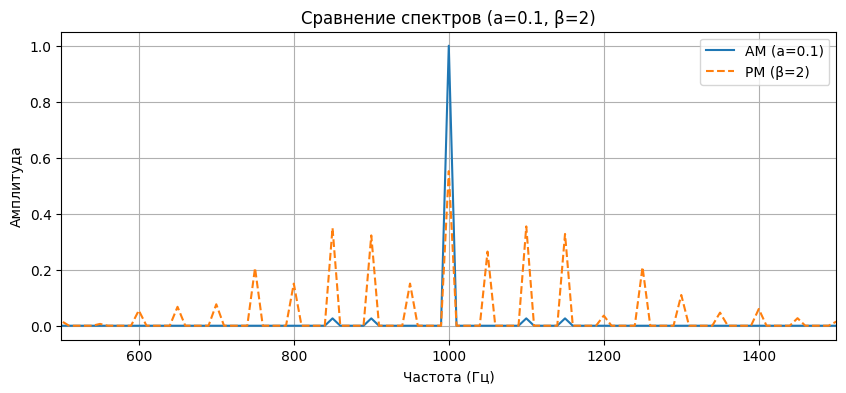

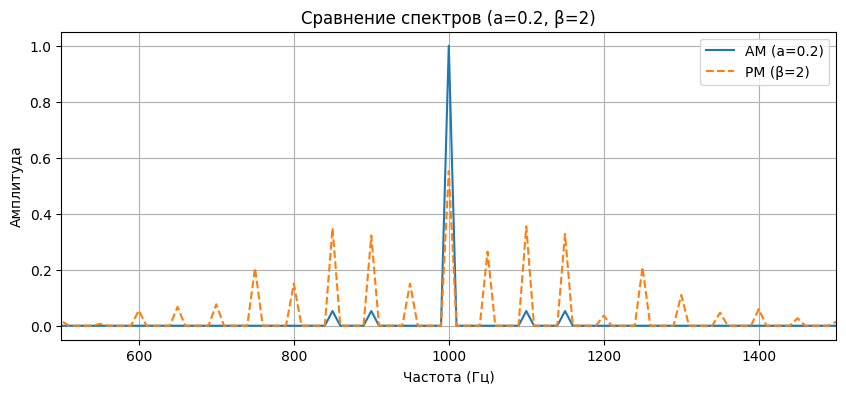

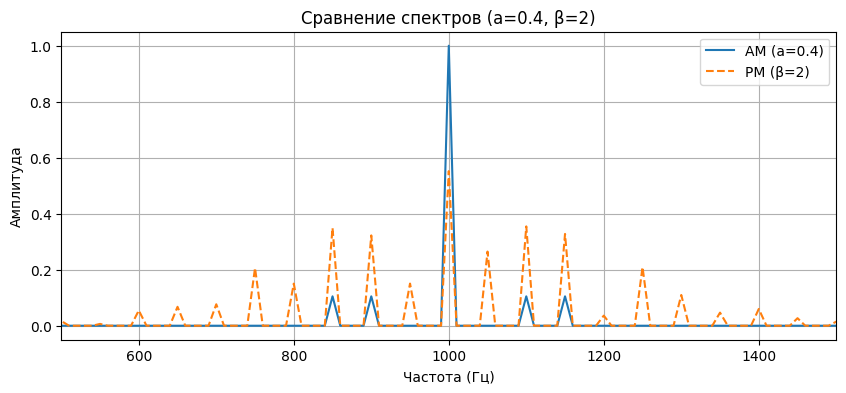

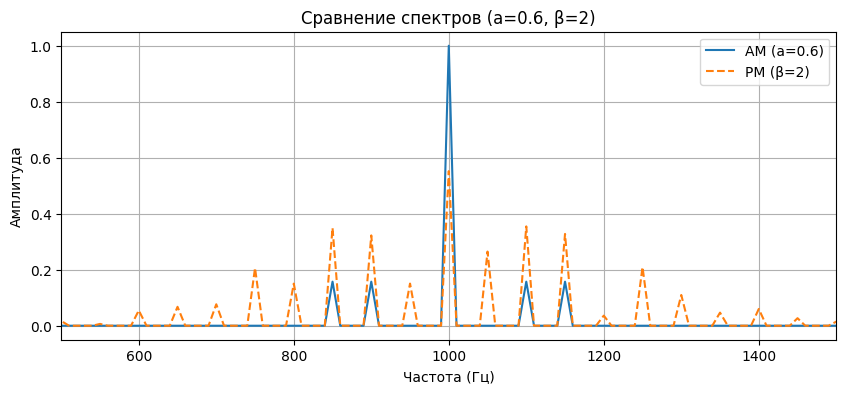

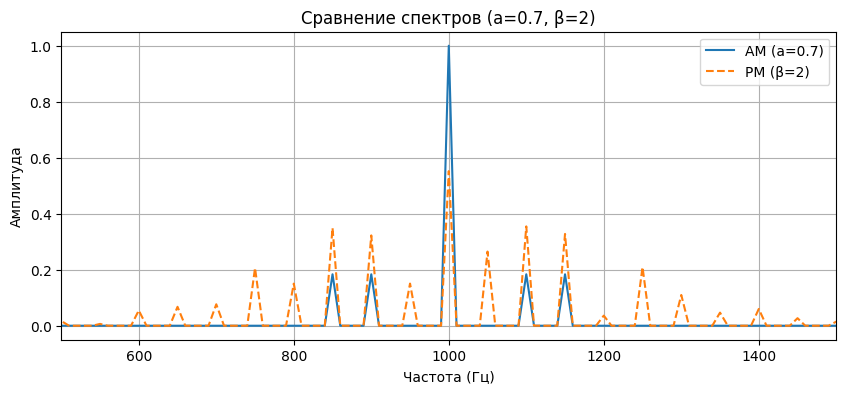

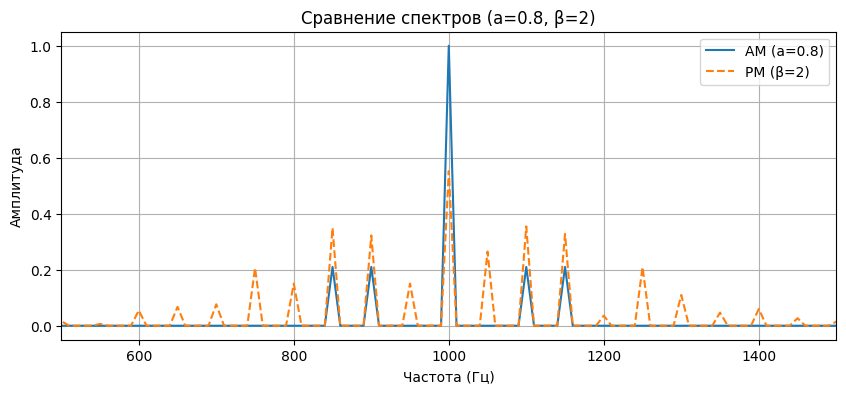

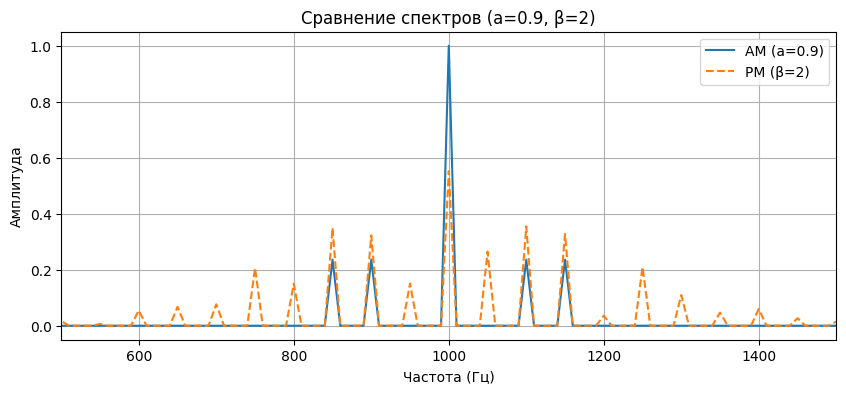

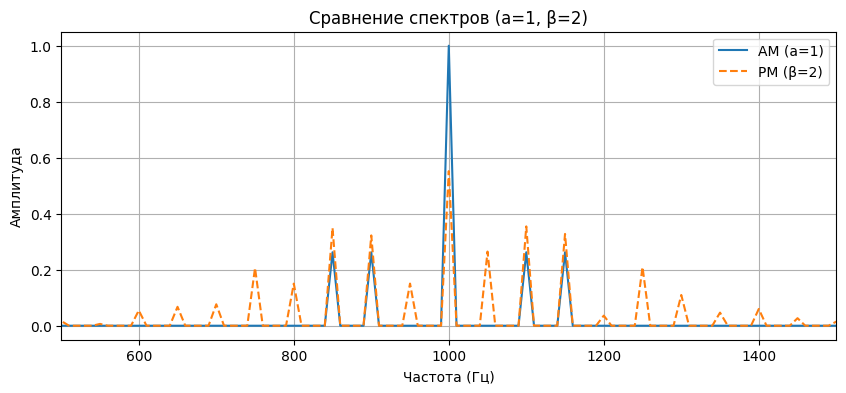

In [85]:
fc_high = 10000
Ac = 1
beta_pm_audio = 2

def plot_spectrum(signal, fs, title, ax, color='b', label=None):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    fft_vals = fft_vals[:n//2]
    freq = np.fft.fftfreq(n, 1/fs)[:n//2]
    amp = np.abs(fft_vals) / n
    ax.semilogy(freq, amp, color=color, label=label)
    ax.set_xlim([0, fs/2])
    ax.set_xlabel('Частота, Гц')
    ax.set_ylabel('Амплитуда')
    ax.set_title(title)
    ax.grid(True)
    if label:
        ax.legend()
a_am_values = [0.15, 0.45, 0.75, 1.0]

fig, axes = plt.subplots(len(a_am_values), 1, figsize=(12, 4*len(a_am_values)))

for idx, a_am in enumerate(a_am_values):

    s_am = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

    s_pm = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

    ax = axes[idx]
    plot_spectrum(s_am, fs_audio, f'АМ, a_am = {a_am}', ax, 'blue', 'AM')
    plot_spectrum(s_pm, fs_audio, f'ФМ, β = {beta_pm_audio}', ax, 'red', 'FM')
    ax.set_title(f'a_am = {a_am}')

plt.tight_layout()
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

Наиболее подходящий АМ-сигнал в диапазоне от 0.8 до 1.
При выбранных параметрах заметные искажения:

для АМ-сигнала начинают проявляться уже при амплитуде шума около 0.03–0.05
для ФМ-сигнала — при более высоких значениях, примерно 0.08–0.1